In [1]:
import pandas as pd
import numpy as np
import sys
import warnings
warnings.filterwarnings('ignore')
from copy import deepcopy,copy
from datetime import datetime
import pickle
import os

# Import Machine Scientist
from importlib.machinery import SourceFileLoader
# Get the absolute path of the script's directory
script_dir = os.getcwd()
# Define the relative path to the module
relative_module_path = "rguimera-machine-scientist-constrained/machinescientist_ode.py"
path = os.path.join(script_dir, relative_module_path)
ms = SourceFileLoader("ms", path).load_module()


folder_name = 'Train_test_data_lin_term_com2025_03_11-11_21_44'
with open(f'./{folder_name}/x.pkl', 'rb') as file:
    # A new file will be created
    x = pickle.load(file)
    
with open(f'./{folder_name}/y.pkl', 'rb') as file:
    # A new file will be created
    y = pickle.load(file)


f_name='Full_data_lin_term_prod_2025_03_27-06_00_44/mdl_refit_train1.pkl'
file = open(f_name,'rb')
train_bms = pickle.load(file)
print('Train model', train_bms, train_bms.E)

Train model ((_a0_ * B) * (((exp((B * _a2_)) * (_a4_ * B)) ** (B ** 3)) + _a6_)) -17227.5844223750


In [2]:
string = f'((((exp((B * _a2_)) * (_a4_ * B)) ** (B ** 3)) * (_a1_ * B)) - (_a0_ * B))'
string = f'((_a0_ * B) - (((exp((B * _a2_)) * (_a4_ * B)) ** (B ** 3)) * (_a1_ * B)))'
print(string)
bms_fulldata_new = ms.from_string_model(x, y,string , 1, 8, ['B'])
#bms_fulldata_new.fit_par={}
#bms_fulldata_new.x0[str(bms_fulldata_new)]=deepcopy(bms_fulldata.x0[str(bms_fulldata)])
#bms_fulldata_new.par_values=deepcopy(bms_fulldata.par_values)
#bms_fulldata_new.get_bic(reset=True,fit=False)
#bms_fulldata_new.get_energy(reset=True)
print('New Train (recovered pars)',bms_fulldata_new.E,bms_fulldata_new.EB,bms_fulldata_new.EP)
#bms_fulldata_new=deepcopy(bms_fulldata)
print(bms_fulldata_new.E)

bms_fulldata_new.par_values = train_bms.par_values
bms_fulldata_new.fit_par={}
bms_fulldata_new.get_bic(reset=True,fit=True)
bms_fulldata_new.get_energy(reset=True)

print('Refit energy:',bms_fulldata_new.E)

((_a0_ * B) - (((exp((B * _a2_)) * (_a4_ * B)) ** (B ** 3)) * (_a1_ * B)))
Model summary
Par_values: {'B5': {'_a0_': 30.449413847625614, '_a2_': -1.6044723343314815, '_a4_': 4.366870612368027, '_a1_': 30.434182683128956}, 'A8': {'_a0_': -0.04296943088984378, '_a2_': 15.673769795181657, '_a4_': 2.257528689849247e-07, '_a1_': -0.15660199341680278}, 'G7': {'_a0_': 36.78287574994982, '_a2_': -1.5804403925551547, '_a4_': 4.3767009095017455, '_a1_': 36.59387391287961}, 'A9': {'_a0_': -0.7472512914769129, '_a2_': 3.920761828375685, '_a4_': 0.07036508254213192, '_a1_': -0.9063823498889224}, 'F7': {'_a0_': 21.154751726380237, '_a2_': -1.749026814667218, '_a4_': 4.880999686548076, '_a1_': 21.03376533968057}, 'G8': {'_a0_': 2.261200255008797, '_a2_': -7.897034025781756, '_a4_': 297.0763576881411, '_a1_': 1.9770578661238947}, 'D12': {'_a0_': 16.66264811333746, '_a2_': -1.5619481941484243, '_a4_': 4.386701059968548, '_a1_': 16.4959572455863}, 'H12': {'_a0_': 0.028636140616458052, '_a2_': -266894.48

In [3]:
old_par_values=deepcopy(bms_fulldata_new.par_values)
old_cols=list(old_par_values.keys())


print('Energy before refitting:',bms_fulldata_new.E)
old_energy = deepcopy(bms_fulldata_new.E)


f_name=f'mdl_mod_model1.pkl'
file = open(f_name,'wb')
pickle.dump(bms_fulldata_new,file)
file.close()


for o_col in old_cols:
    for n_col in old_cols:
        #print(o_col,n_col)
        #test_model=deepcopy(bms_fulldata_new)
        bms_fulldata_new.fit_par={}
        p=deepcopy(bms_fulldata_new.par_values[n_col])
        bms_fulldata_new.par_values[n_col]=deepcopy(old_par_values[o_col])
        bms_fulldata_new.get_bic(reset=True,fit=True)
        bms_fulldata_new.get_energy(reset=True)
        if bms_fulldata_new.E<old_energy and not np.isinf(float(bms_fulldata_new.E)):
            print('Better fit. Update model.',bms_fulldata_new.E)
            old_energy=deepcopy(bms_fulldata_new.E)
            file = open(f_name,'wb')
            pickle.dump(bms_fulldata_new,file)
            file.close()
        else:
            # Not improving energy. Setting previorus parameters
            bms_fulldata_new.par_values[n_col]=deepcopy(p)

Energy before refitting: -14518.5316766300
Better fit. Update model. -14602.8990213711
Better fit. Update model. -14609.8967350161
Better fit. Update model. -14612.2930092968
Better fit. Update model. -14780.4873208554
Better fit. Update model. -14782.9082157258
Better fit. Update model. -14809.4618947930
Better fit. Update model. -14812.0807553482
Better fit. Update model. -14925.7835908946
Better fit. Update model. -14925.8750281166
Better fit. Update model. -14955.0992449388
Better fit. Update model. -14955.1421269536
Better fit. Update model. -14976.8287263849
Better fit. Update model. -14996.6970421425
Better fit. Update model. -15026.9455073842
Better fit. Update model. -15026.9937338133
Better fit. Update model. -15026.9951250149
Better fit. Update model. -15027.0071358919
Better fit. Update model. -15027.0174950836
Better fit. Update model. -15027.0264810343
Better fit. Update model. -15027.0352071468
Better fit. Update model. -15027.8900275953
Better fit. Update model. -15029.

KeyboardInterrupt: 

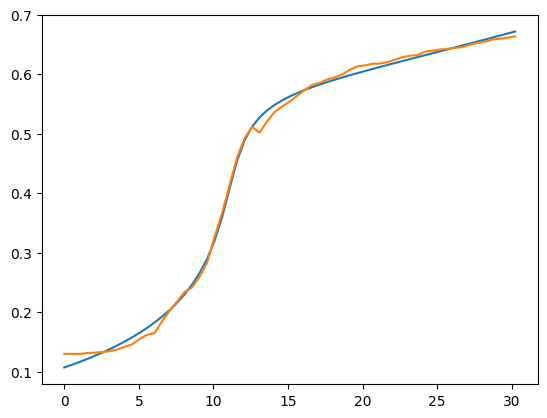

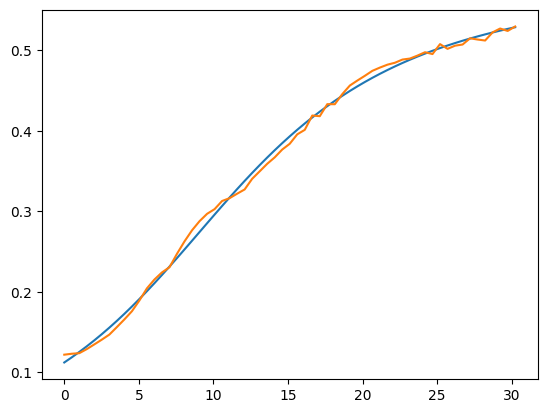

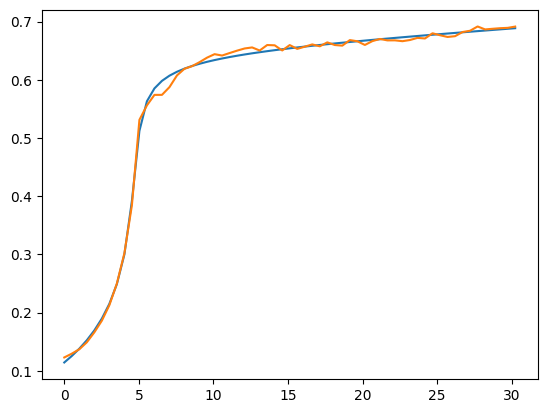

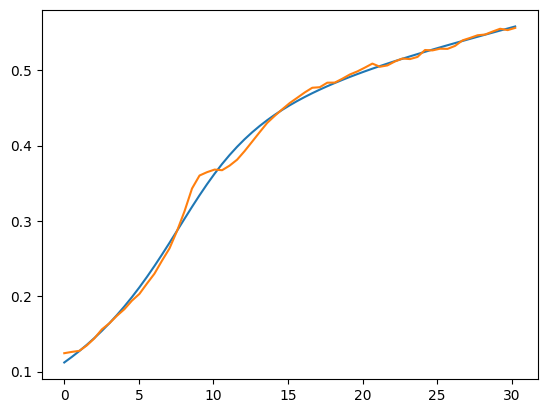

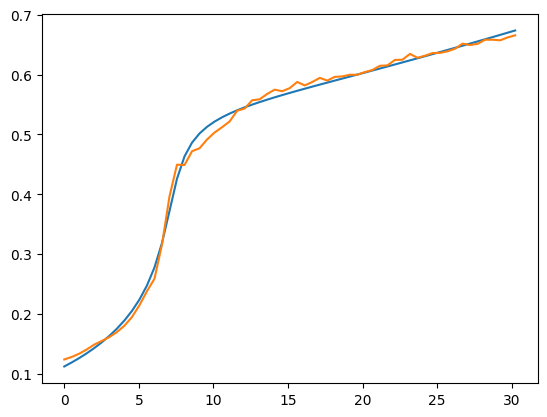

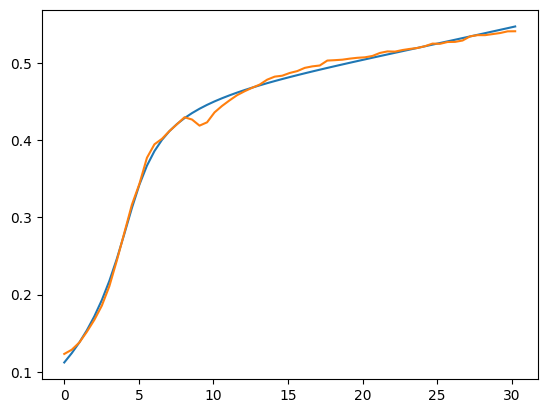

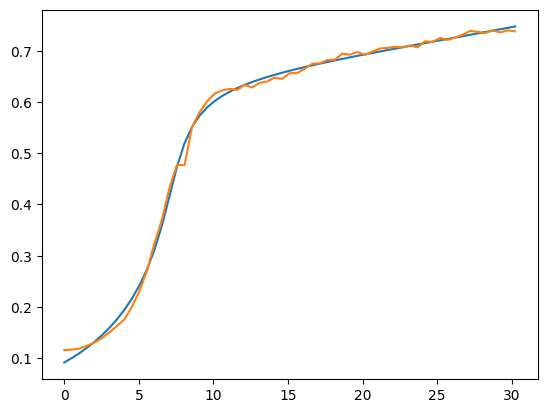

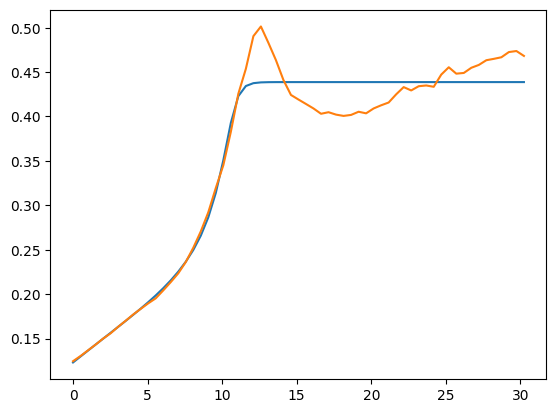

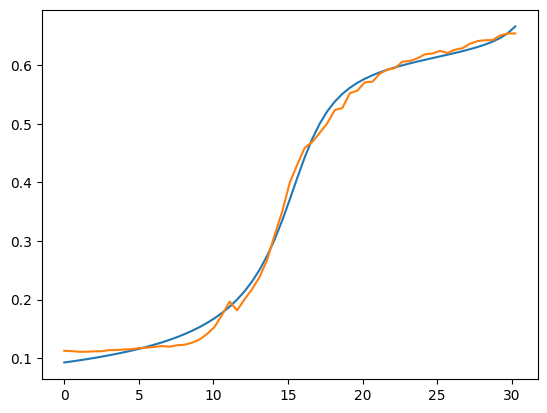

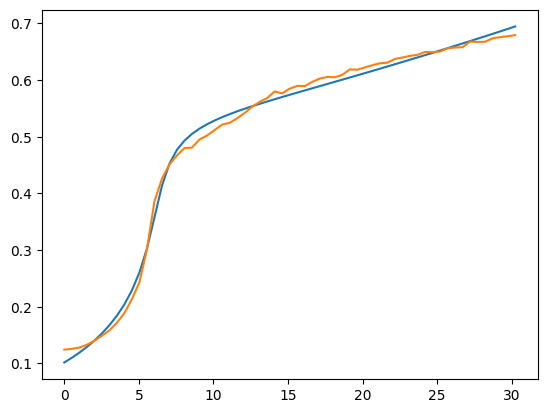

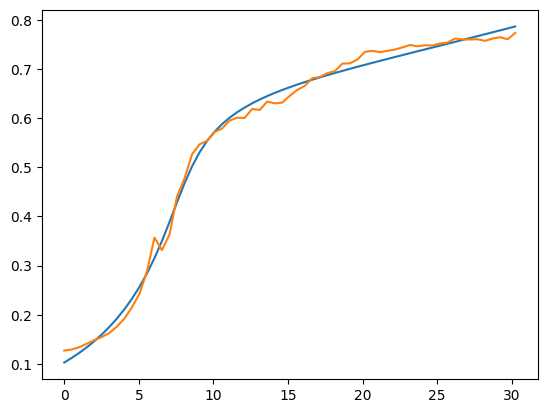

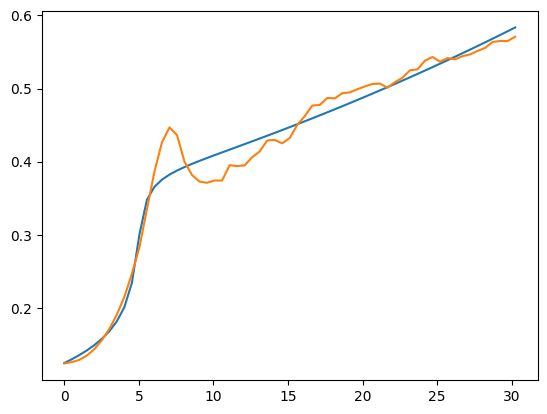

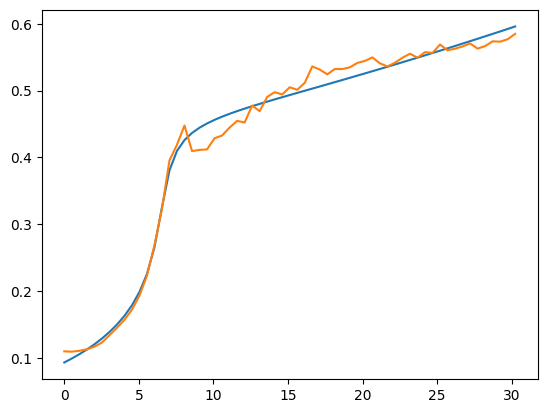

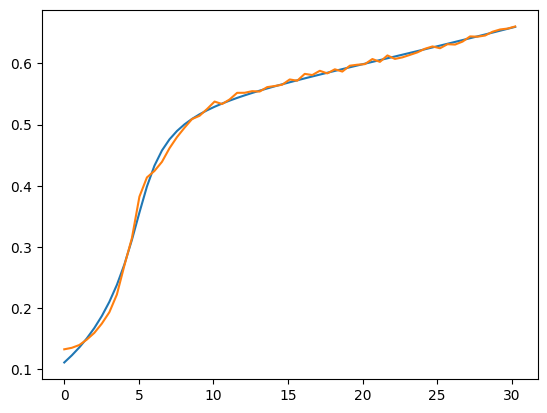

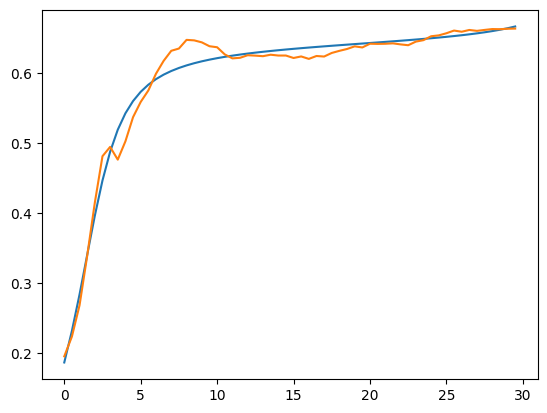

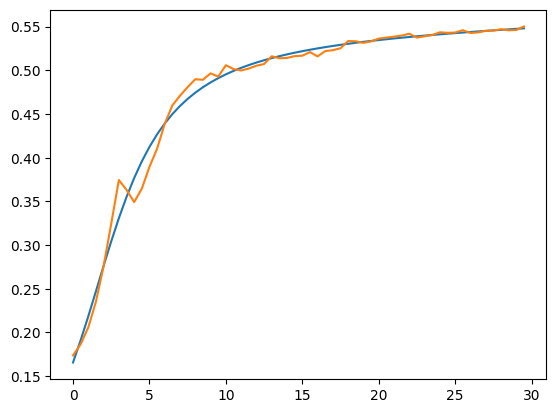

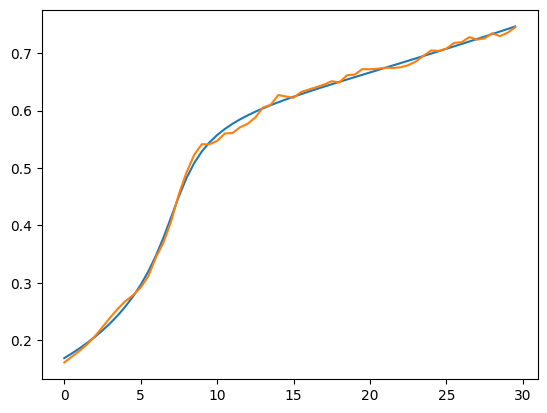

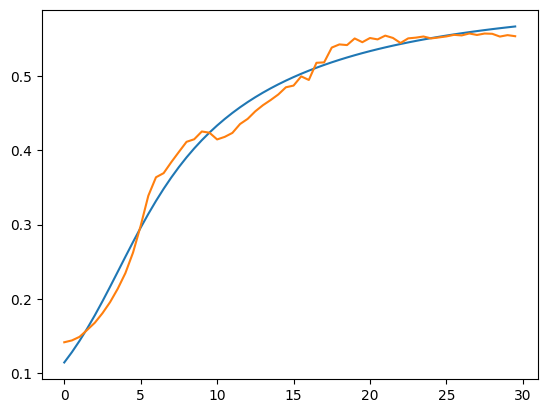

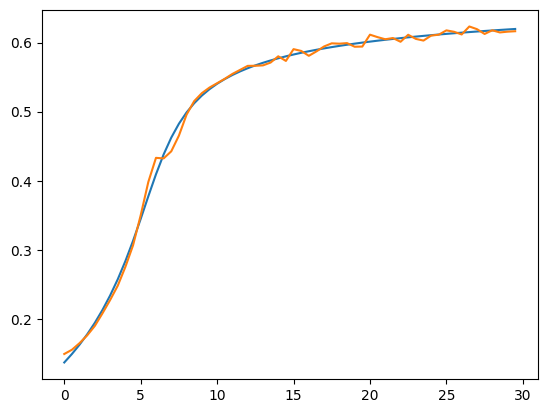

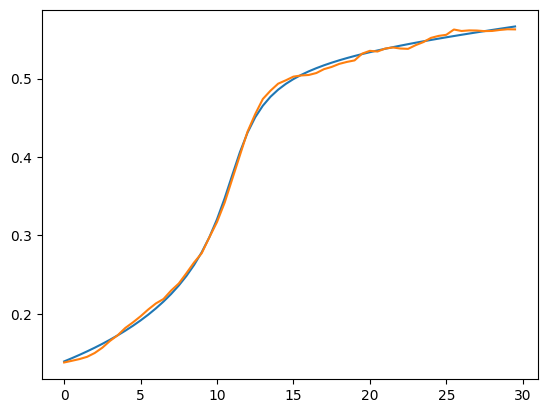

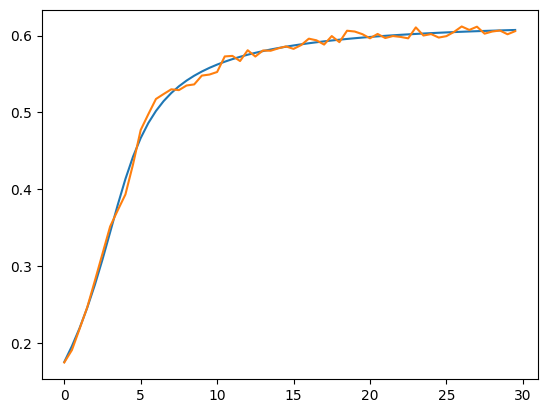

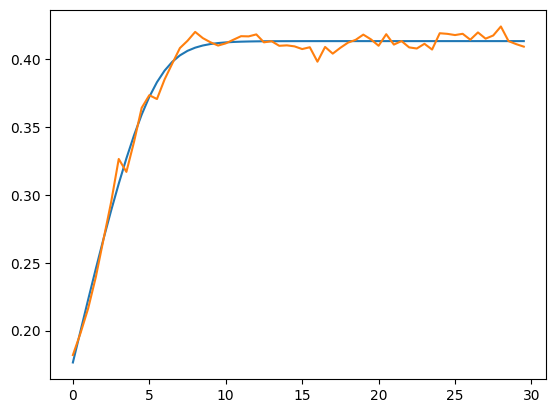

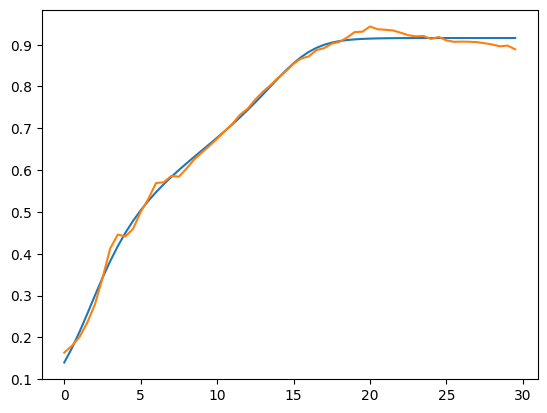

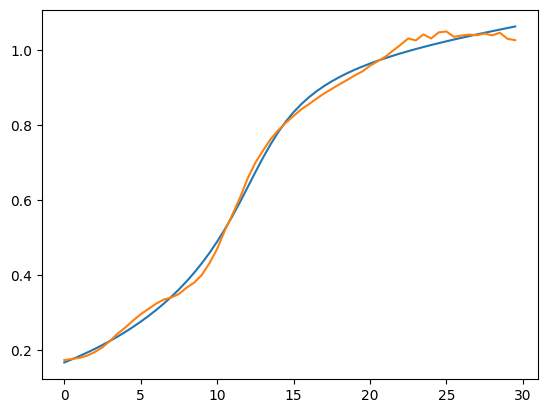

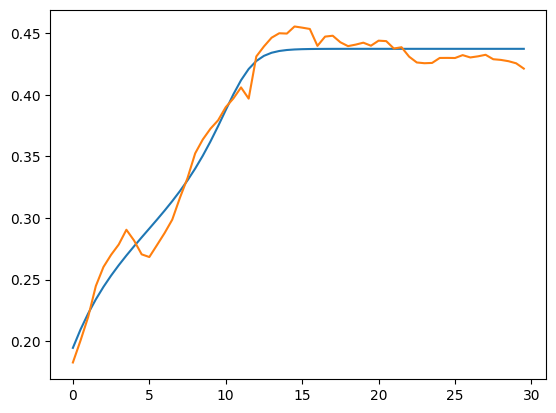

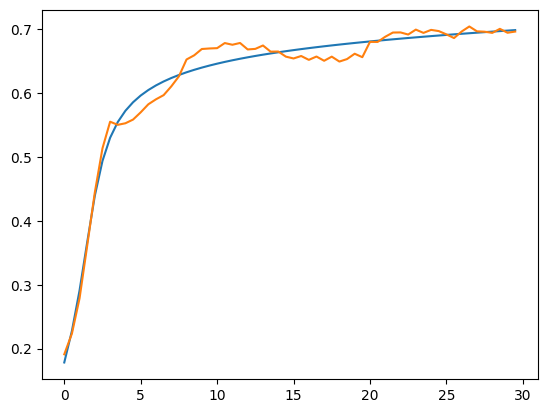

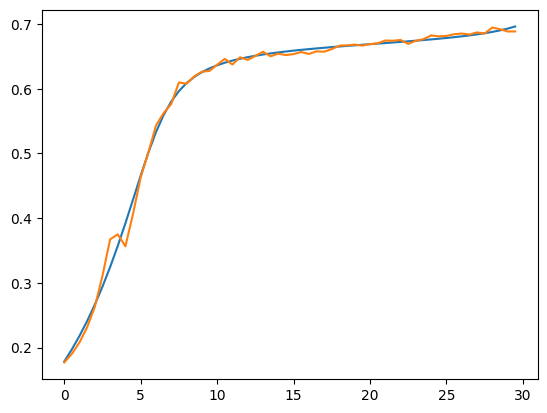

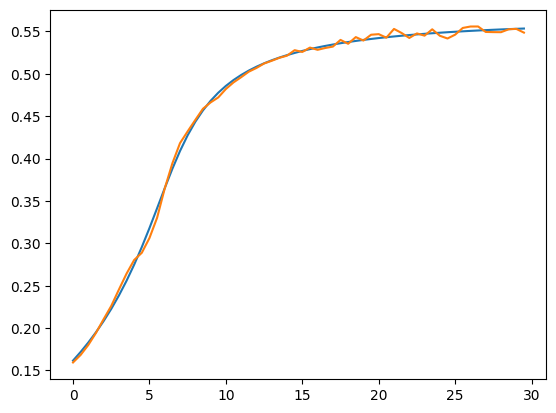

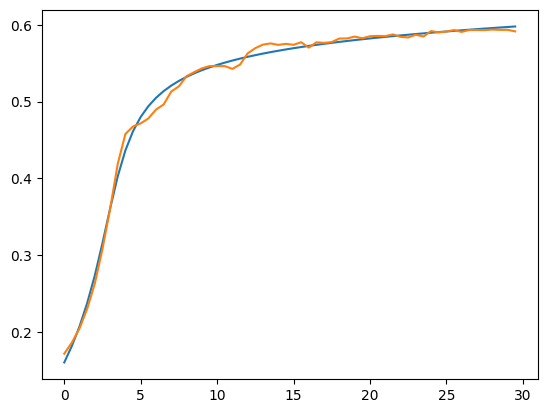

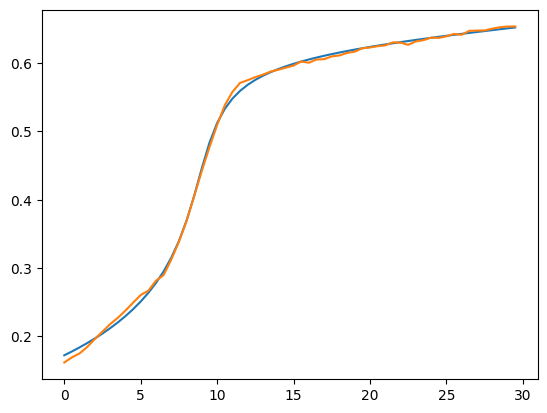

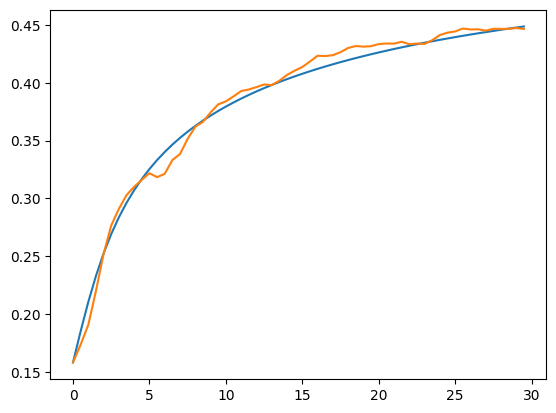

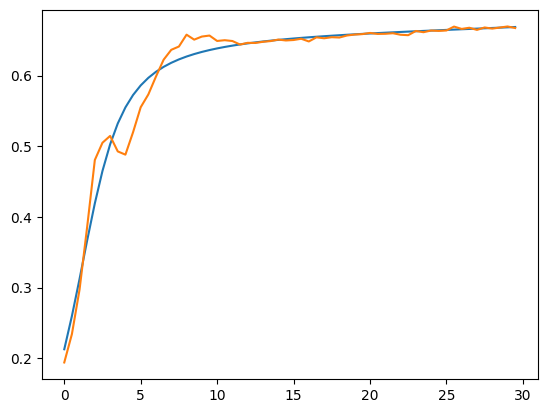

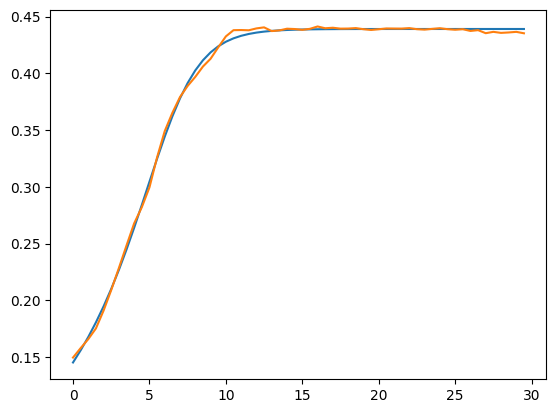

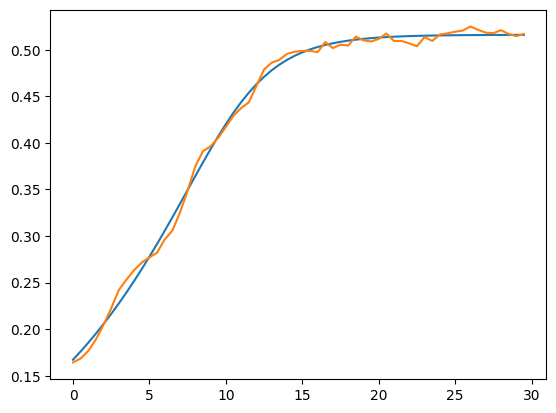

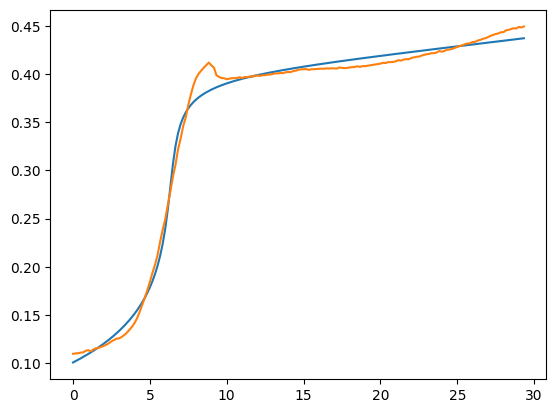

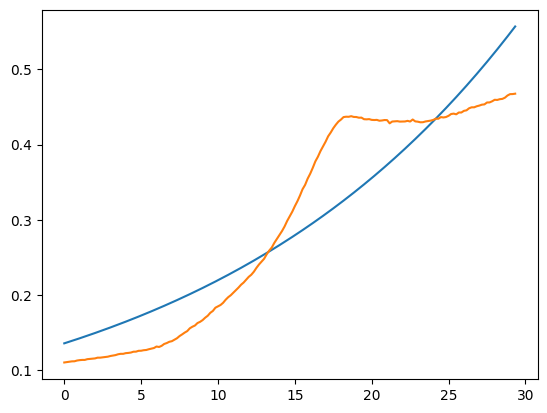

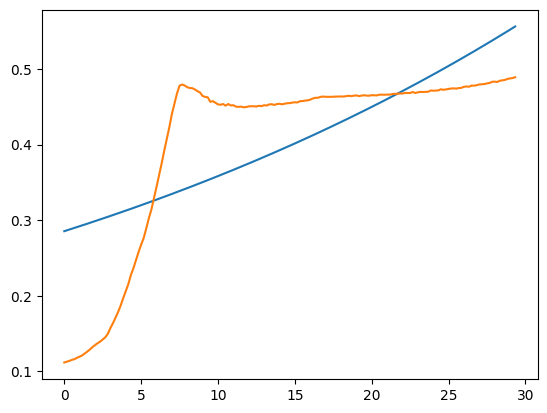

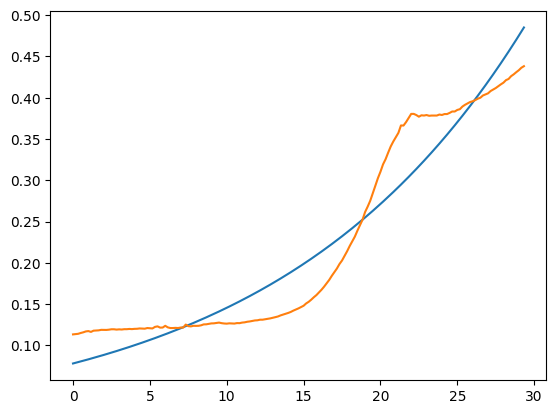

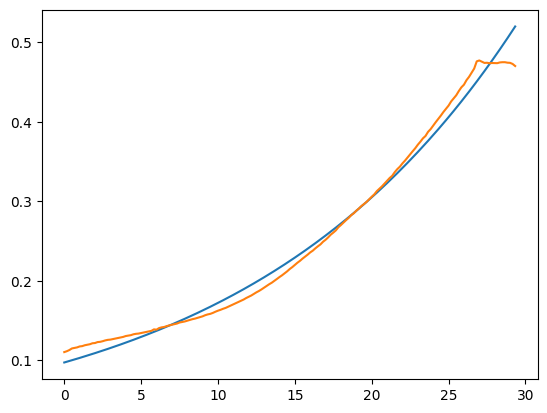

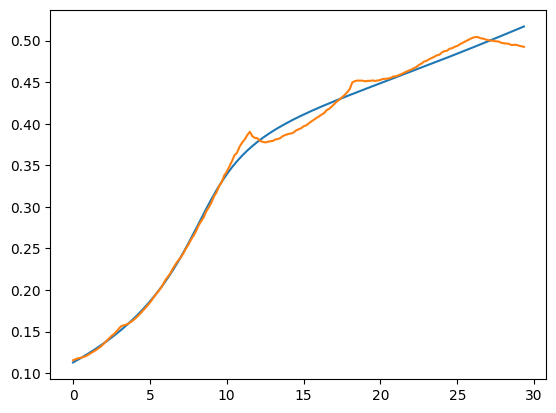

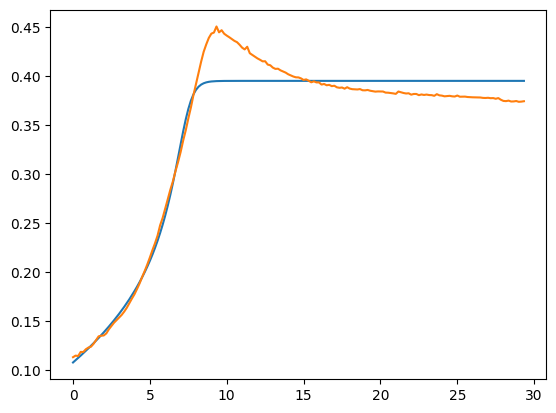

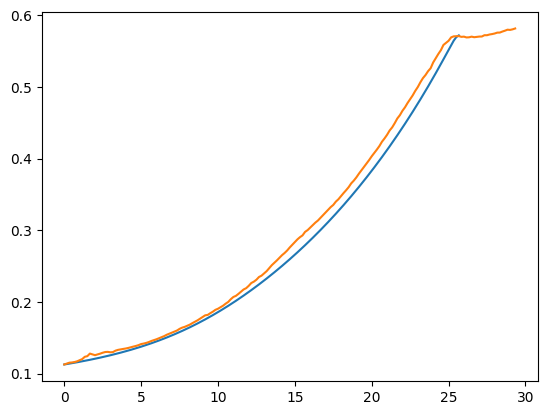

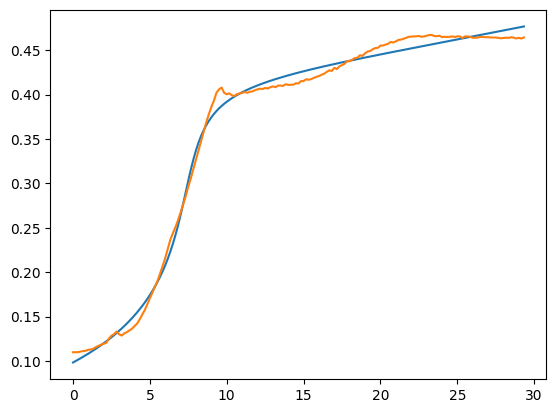

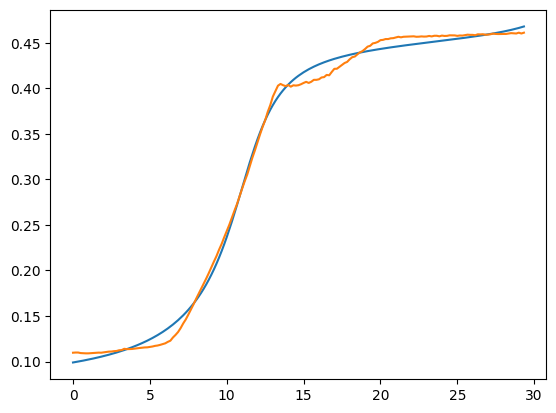

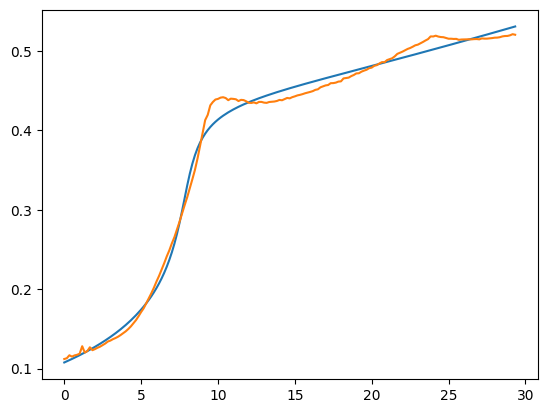

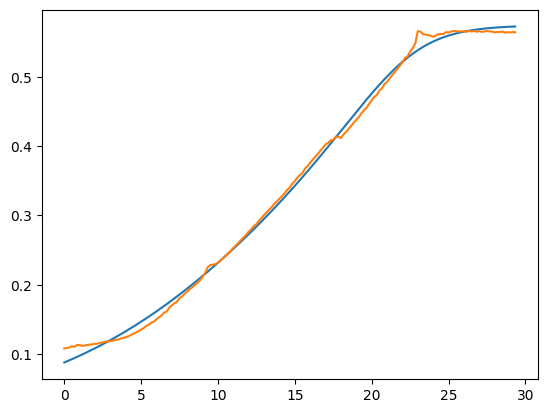

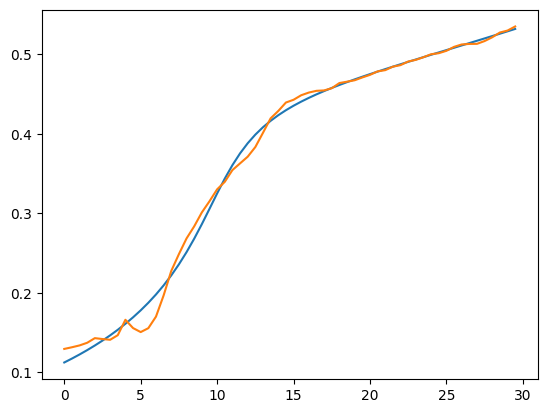

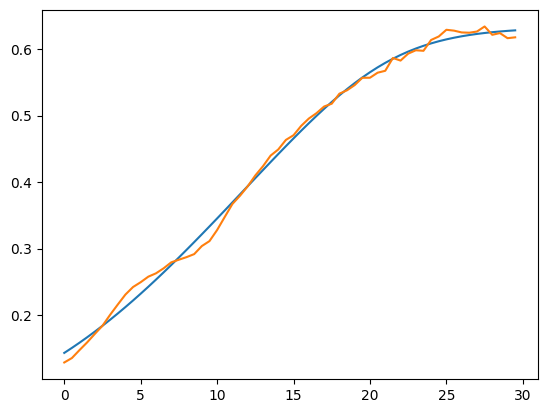

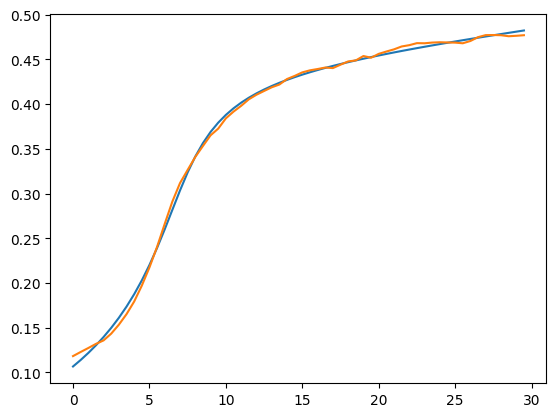

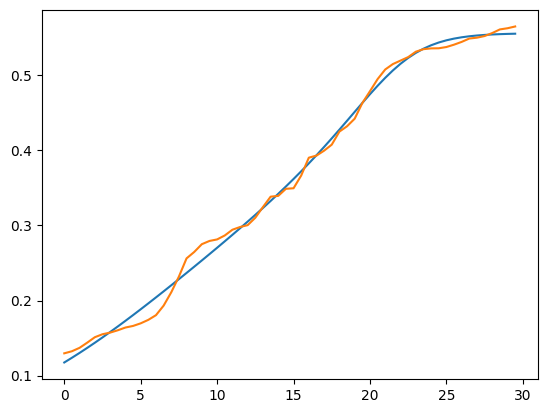

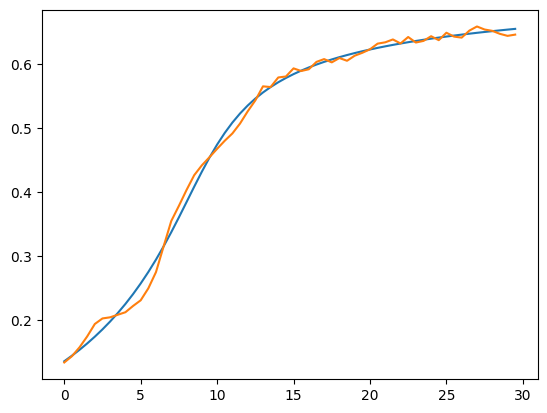

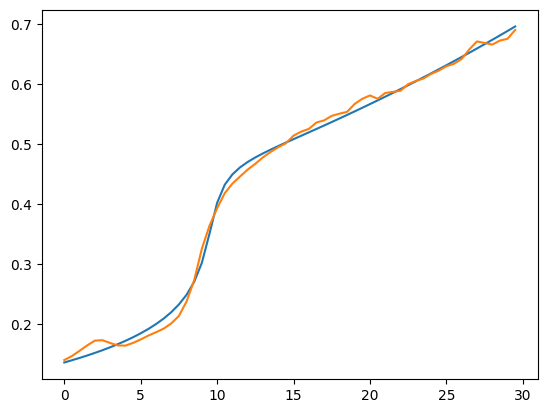

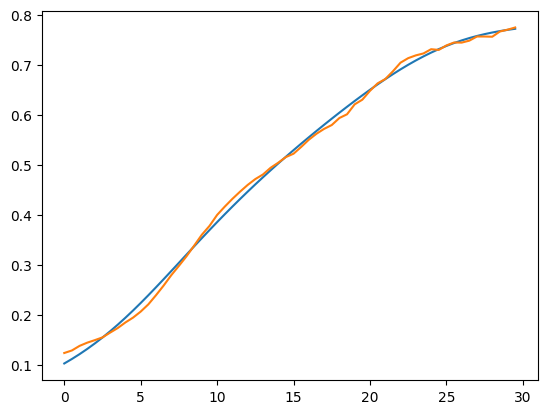

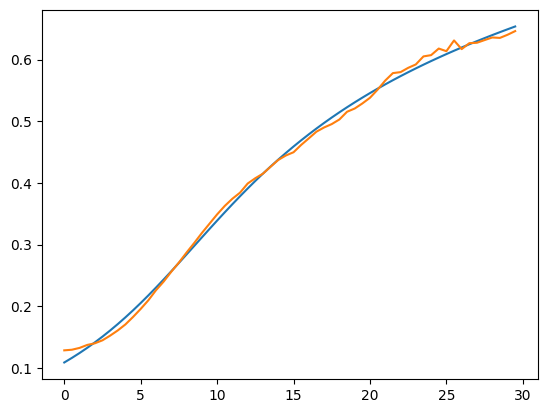

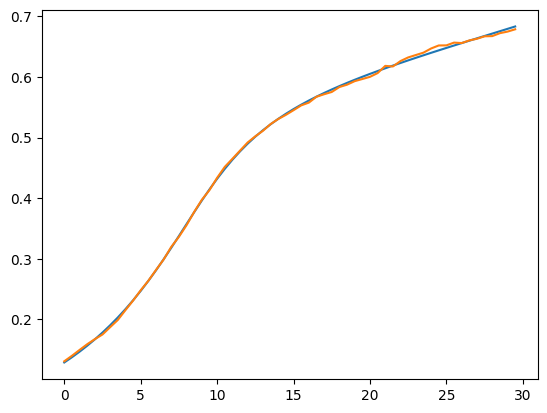

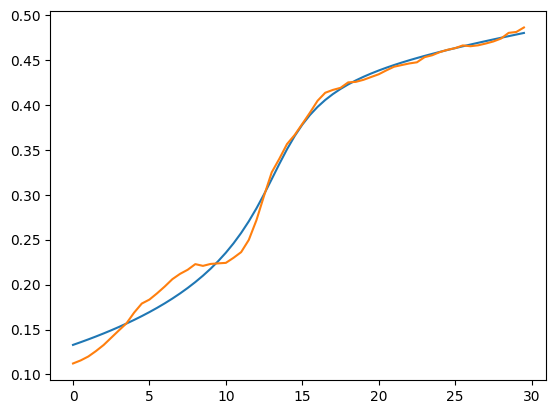

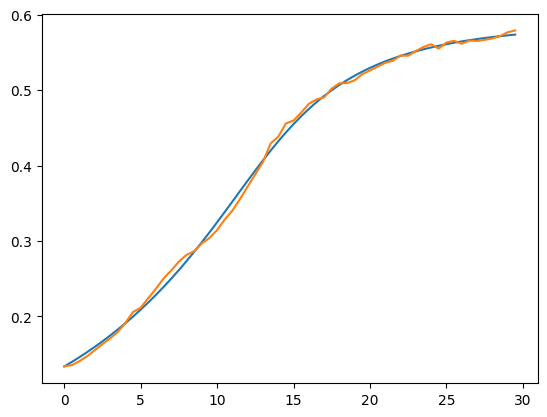

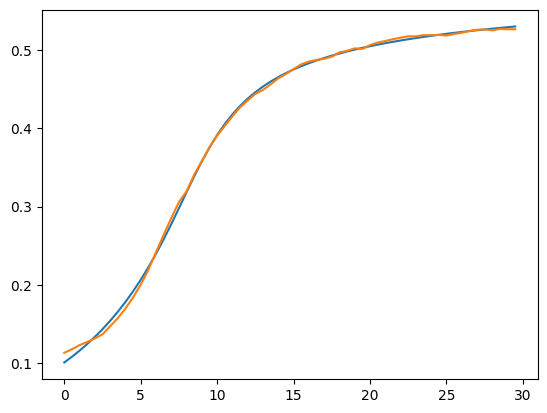

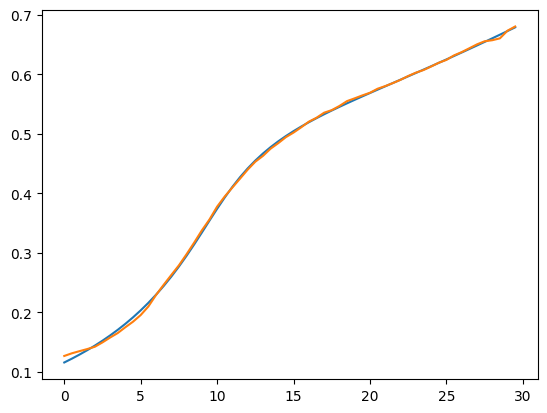

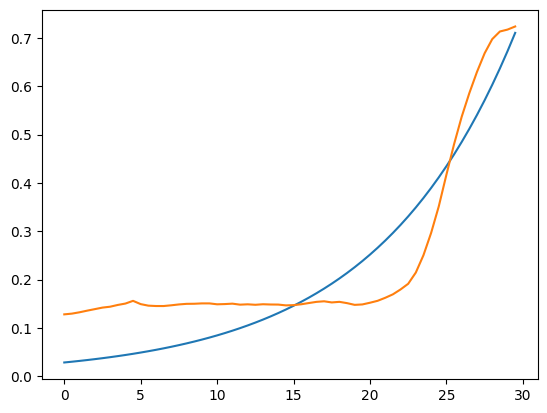

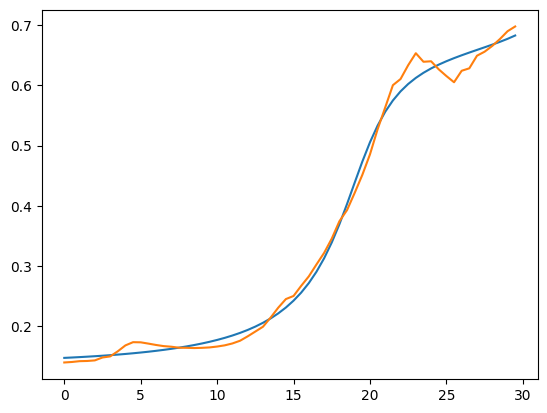

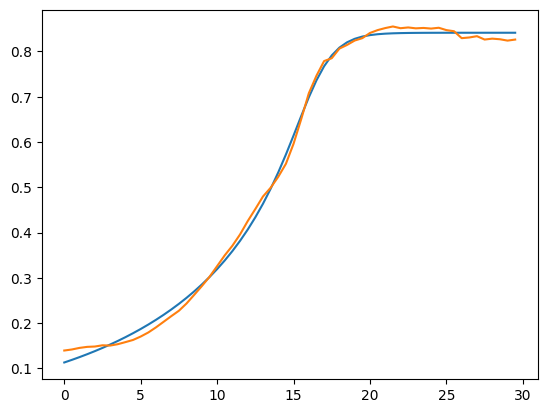

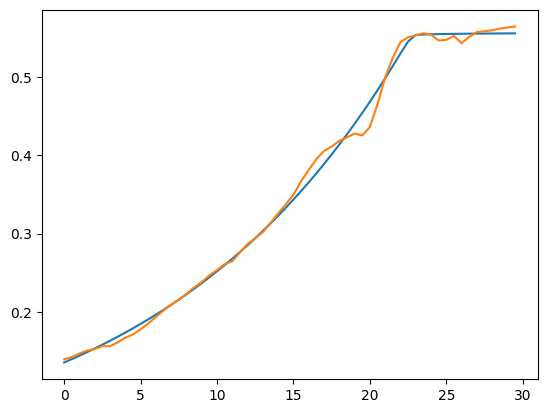

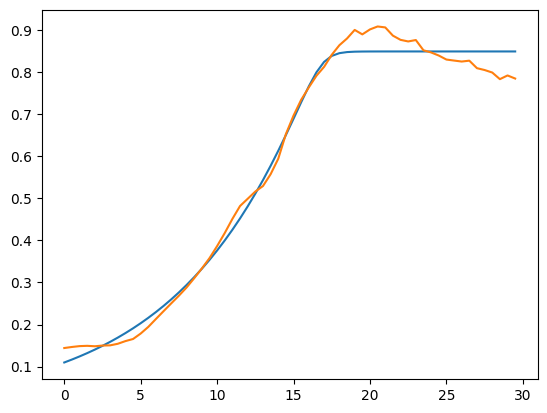

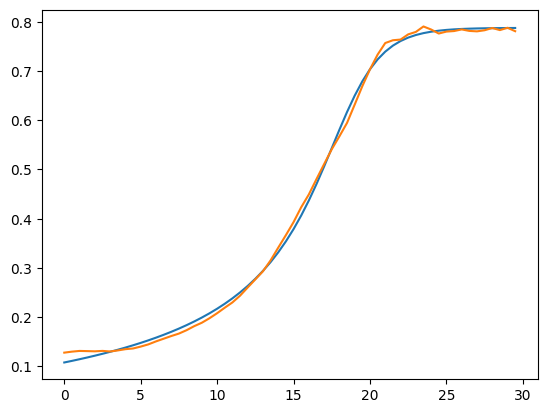

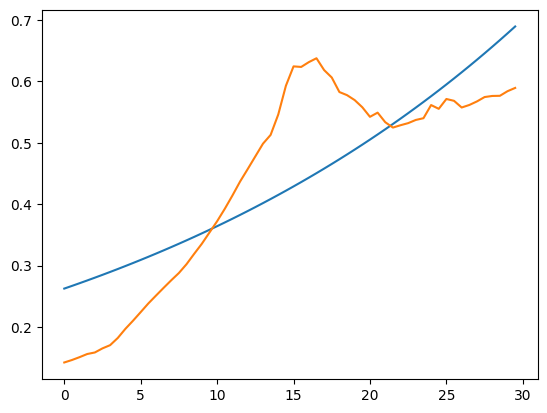

In [4]:
import matplotlib.pyplot as plt

# Plotting B(t) real and predicted
def euler_BMS(model,y0,h,steps,col):
    res=[y0]
    for i in range(steps-1):
        f=model.predict({col:pd.DataFrame(data={'B':[res[-1]]})})[col].to_numpy()[0]
        res.append(res[-1]+h*f)
    return res

def trap_BMS(model,y0,h,steps,col):
    res=[y0]
    for i in range(steps-1):
        f=model.predict({col:pd.DataFrame(data={'B':[res[-1]]})})[col].to_numpy()[0]
        y1=res[-1]+h*f
        f1=model.predict({col:pd.DataFrame(data={'B':[y1]})})[col].to_numpy()[0]
        res.append(res[-1]+0.5*h*(f+f1))
    return res

def RK_BMS(model,y0,h,steps,col):
    res=[y0]
    for i in range(steps-1):
        k1 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]]})})[col].to_numpy()[0]
        k2 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]+k1/2.]})})[col].to_numpy()[0]
        k3 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]+k2/2.]})})[col].to_numpy()[0]
        k4 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]+k3]})})[col].to_numpy()[0]

        # Calculate new x and y
        res.append(res[-1] + 1./6*(k1+2*k2+2*k3+k4))
        """x = x + dx
        f=model.predict({col:pd.DataFrame(data={'B':[res[-1]]})})[col].to_numpy()[0]
        res.append(res[-1]+h*f)"""
    return res

for col in list(x.keys()) :
    # Integrate ODE with BMS expression
    h=x[col].t[1]-x[col].t[0]
    y0=bms_fulldata_new.x0[str(bms_fulldata_new)][col]
    train_ode_fulldata=RK_BMS(bms_fulldata_new,y0,h,len(y[col]),col)
    plt.plot(x[col].t.to_numpy(),train_ode_fulldata)
    plt.plot(x[col].t.to_numpy(),x[col].B.to_numpy())
    plt.show()

In [5]:
print(bms_fulldata_new.par_values)
print(bms_fulldata_new)
print(bms_fulldata_new.E)

{'B5': {'_a0_': 0.010060431070148347, '_a2_': -187.70814648215088, '_a4_': 8.87154232543538e+41, '_a1_': -0.0639827855399125}, 'A8': {'_a0_': -0.042968577953198785, '_a2_': 15.673812819672282, '_a4_': 2.257302891915937e-07, '_a1_': -0.1566011858727683}, 'G7': {'_a0_': 0.002687029773829539, '_a2_': -147.95768535195586, '_a4_': 2.291970258592953e+35, '_a1_': -0.16351359694419731}, 'A9': {'_a0_': 0.009047683793580038, '_a2_': -96.22367687442706, '_a4_': 21558829556.708817, '_a1_': -0.11466041765087316}, 'F7': {'_a0_': 0.010913924009645574, '_a2_': -227.771135512988, '_a4_': 9.298134947317932e+46, '_a1_': -0.09351352996244211}, 'G8': {'_a0_': 0.007850673674180611, '_a2_': -246.2780035403972, '_a4_': 1.7500748735469016e+35, '_a1_': -0.18070120020137706}, 'D12': {'_a0_': 0.007201276563675528, '_a2_': -83.62298243367391, '_a4_': 4.0338499154958116e+18, '_a1_': -0.1652765768608793}, 'H12': {'_a0_': -115.95156579114837, '_a2_': -2.858993858957545, '_a4_': 7.834520829563201, '_a1_': -116.1442623

In [6]:
rows = []
for dataset, params in bms_fulldata_new.par_values.items():
    a0 = params.get("_a0_")
    a2 = params.get("_a2_")
    a4 = params.get("_a4_")
    a1 = params.get("_a1_")

    row = {
        "Dataset": dataset,
        "r": a0,
        "c1":a2,
        "c2":a4,
    }
    rows.append(row)

# Save to CSV
df = pd.DataFrame(rows)
display(df)
df.to_csv("model_mod_parameters.csv", index=False)

,Dataset,r,c1,c2
0,B5,0.010060,-1.877081e+02,8.871542e+41
1,A8,-0.042969,1.567381e+01,2.257303e-07
2,G7,0.002687,-1.479577e+02,2.291970e+35
3,A9,0.009048,-9.622368e+01,2.155883e+10
4,F7,0.010914,-2.277711e+02,9.298135e+46
...,...,...,...,...
61,R.S.19 L-Pyro-Glutamate.1_19,-0.497234,-3.965146e+00,2.462712e+01
62,R.S.19 Thiourea_19,0.062005,2.468508e+02,6.093826e-08
63,R.S.19 L-Glutathione_19,0.126838,1.034272e+01,5.921547e-02
64,R.S.19 Histamine_19,5.851385,-1.055570e+00,2.967011e+00
